#Zadanie: kupujemy mieszkanie

In [1]:
import numpy as np

In [4]:
import sys
!{sys.executable} -m pip install numpy-financial as npf


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\micha\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [11]:
import numpy_financial as npf

In [12]:
import sys
!{sys.executable} -m pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------- ------------------------------ 1.8/8.1 MB 12.9 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 19.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 16.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 30.6 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.3 MB 30.6 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.3 MB 30.6 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.3 MB 30.6 MB/s eta 0:00:01
   -------------------------- ------------- 1.6/2.3 MB 1.5 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.3 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 1.6 MB/s  0:00:01
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   -----------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\micha\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [13]:
import matplotlib.pyplot as plt

In [16]:
P0 = 120000        # cena startowa
r = 0.05           # 5% rocznie
t = 5              # lata

price_future = P0 * (1 + r) ** t

#TYLE_ZDROZEJE_MIESZKANIE

In [27]:
print(round(price_future))

153154


#DANE_LOKATY

In [22]:
annual_rate = 0.12   #roczna stopa %
monthly_rate = annual_rate / 12 #miesieczna stopa %
n_months = 5 * 12 # zmiana lat na miesiace

In [23]:
fv = price_future  # ile potrzebujesz

In [24]:
payment = npf.pmt(monthly_rate, n_months, 0, -fv) # obliczenie miesięcznej wpłaty

#TYLE TRZEBA ODKŁADAĆ

In [26]:
print(round(payment))

1875


#SYMULACA_WZROSTU_CEN

In [31]:
months = np.arange(n_months +1)  #wektor czasu

In [32]:
monthly_growth=(price_future - P0) / n_months  #ile miesiecznie rosnie cena (liniowy model)

In [33]:
house_price = P0 + monthly_growth * months  # tablica cen w czasie ( start od P0 i dodajemy co miesiac staly %

In [34]:
print(house_price)

[120000.       120552.563125 121105.12625  121657.689375 122210.2525
 122762.815625 123315.37875  123867.941875 124420.505    124973.068125
 125525.63125  126078.194375 126630.7575   127183.320625 127735.88375
 128288.446875 128841.01     129393.573125 129946.13625  130498.699375
 131051.2625   131603.825625 132156.38875  132708.951875 133261.515
 133814.078125 134366.64125  134919.204375 135471.7675   136024.330625
 136576.89375  137129.456875 137682.02     138234.583125 138787.14625
 139339.709375 139892.2725   140444.835625 140997.39875  141549.961875
 142102.525    142655.088125 143207.65125  143760.214375 144312.7775
 144865.340625 145417.90375  145970.466875 146523.03     147075.593125
 147628.15625  148180.719375 148733.2825   149285.845625 149838.40875
 150390.971875 150943.535    151496.098125 152048.66125  152601.224375
 153153.7875  ]


In [35]:
print(monthly_growth)

552.5631250000006


#sumulacja lokaty

In [37]:
account = np.zeros(n_months + 1)

for i in range(1, n_months + 1):
    account[i] = account[i-1] * (1 + monthly_rate) + payment

In [38]:
print(account)

[     0.           1875.28353879   3769.31991296   5682.29665088
   7614.40315618   9565.83072653  11536.77257258  13527.4238371
  15537.98161426  17568.64496919  19619.61495767  21691.09464603
  23783.28913128  25896.40556138  28030.65315578  30186.24322613
  32363.38919718  34562.30662794  36783.21323301  39026.32890413
  41291.87573196  43580.07802806  45891.16234713  48225.35750939
  50582.89462327  52964.0071083   55368.93071817  57797.90356414
  60251.16613857  62728.96133874  65231.53449092  67759.13337461
  70312.00824715  72890.41186841  75494.59952588  78124.82905993
  80781.36088932  83464.458037    86174.38615616  88911.41355651
  91675.81123086  94467.85288196  97287.81494956 100135.97663785
 103012.61994301 105918.02968123 108852.49351683 111816.30199079
 114809.74854949 117833.12957377 120886.7444083  123970.89539117
 127085.88788387 130232.03030149 133409.6341433  136619.01402352
 139860.48770254 143134.37611836 146441.00341833 149780.6969913
 153153.7875    ]


#wykres

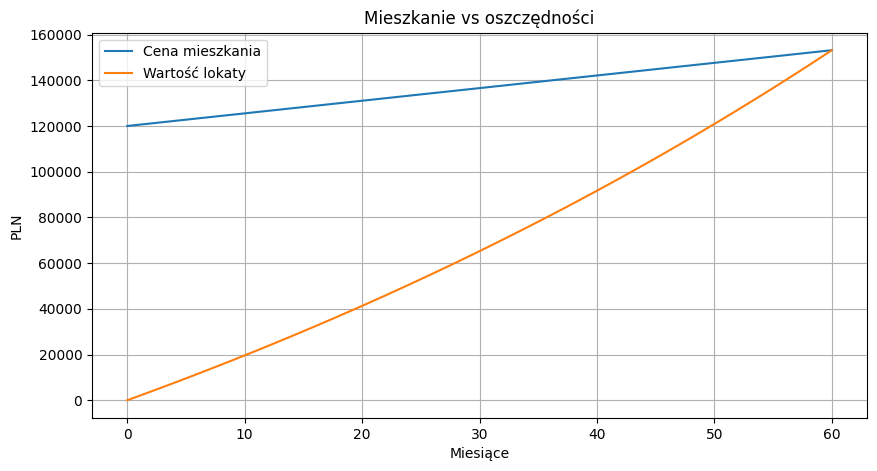

In [39]:
plt.figure(figsize=(10,5))

# cena mieszkania
plt.plot(months, house_price, label="Cena mieszkania")

# lokata
plt.plot(months, account, label="Wartość lokaty")

plt.title("Mieszkanie vs oszczędności")
plt.xlabel("Miesiące")
plt.ylabel("PLN")
plt.legend()
plt.grid()

plt.show()